# Analytical Solution

Rectangular Source Model with a Diagonal Diffusion/Dispersion Tensor.
Assume that we have an infinite domain with a rectangular source at the center of the domain, as shown below. 

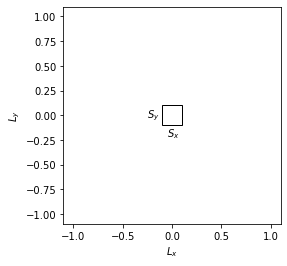

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle as rec

#define Matplotlib figure and axis
fig, ax = plt.subplots()

#equal axis scale
plt.gca().set_aspect('equal', adjustable='box')

#axis label
plt.xlabel('$L_{x}$')
plt.ylabel('$L_{y}$')

#create simple line plot
ax.plot([-1, 1],[-1, 1],linestyle = 'None')

#add rectangle to plot
ax.add_patch(rec((-0.1, -0.1), 0.20, 0.20, linewidth=1, edgecolor='k', facecolor='none'))

#add text
ax.text(-0.25,-0.02,'$S_{y}$')
ax.text(-0.05,-0.22,'$S_{x}$')

#plt.grid()
plt.show()

The analytical solution with initial mass condition can be obtained [Ref1: Charbeneau, R. J. (2006). Groundwater hydraulics and pollutant transport. Waveland Press. Ref2: Shuo Yan, Non-negative numerical solutions of the two-dimensional full-tensor diffusion/dispersion problems using flux-corrected transport, and implementation for the groundwater transport simulator MT3DMS, Master Thesis, 2019.]

$ M=u_{0}S_{x}S_{y} $

$ u(x,y,t)=\frac{u_{0}}{4} \{erf(\frac{x+S_{x}/2}{\sqrt{4D_{L}t}}) - erf(\frac{x-S_{x}/2}{\sqrt{4D_{L}t}})\} \cdot \{erf(\frac{y+S_{y}/2}{\sqrt{4D_{T}t}})-erf(\frac{y-S_{y}/2}{\sqrt{4D_{T}t}}) \} $

where $u_{0}$ is the initial concentration (mol/L); $S_{x}$ and $S_{y}$ are the length of source in x axis and y axis ($m$), respectively; $D_{L}$ and $D_{T}$ are longitudinal and transverse dispersion coefficient ($m^2/s$), respectively; $t$ is the time ($s$).

In [3]:
import numpy as np
from scipy import special
def diffu_conc(x,y,t,u0,Sx,Sy,Dl,Dt):
    erf_x1 = (x+Sx/2.0)/np.sqrt(4.0*Dl*t)
    erf_x2 = (x-Sx/2.0)/np.sqrt(4.0*Dl*t)
    erf_y1 = (y+Sy/2.0)/np.sqrt(4.0*Dt*t)
    erf_y2 = (y-Sy/2.0)/np.sqrt(4.0*Dt*t)
    conc = u0/4.0*(special.erf(erf_x1)-special.erf(erf_x2))*(special.erf(erf_y1)-special.erf(erf_y2))
    return conc

def write_spatial(strfile,t,nx,ny,conc,xc,yc):
    f = open(strfile,"w")
    f.write('title = "dataset ana-diff"\n')
    f.write('variables = "x", "y", "z","tracer"\n') 
    f.write('zone t = "concentration - %r", i = %d, j = %d, k = 1,  f=point\n' %(t,nx,ny))       
    for i in range(0,ny,1):
        for j in range(0,nx,1):
            f.write('%r %r %r %r\n' %(xc[i][j],yc[i][j],0.0,conc[i][j]))
    f.close()
    
def write_transient(strfile,x,y):
    f = open(strfile,"w")
    f.write('title = "dataset ana-diff"\n')
    f.write('variables = "time", "tracer"\n') 
    f.write('zone t = "Concentration", f=point\n') 
    for i in range (1,101,1):
        t = 0.01*i
        conc = max(diffu_conc(xobs,yobs,t,u0,Sx,Sy,Dl,Dt),cmin)
        f.write('%r %r\n' %(t,conc))
    f.close()

# Plot of 2D Structured Grid

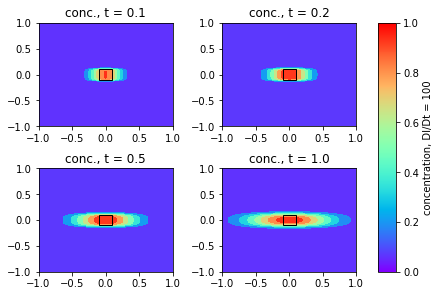

In [5]:
import numpy as np

#define parameters
u0 = 1.0
xmin = -1.0
ymin = -1.0
xmax = 1.0
ymax = 1.0
Lx = xmax-xmin
Ly = ymax-ymin
nx = 100
ny = 100
dx = Lx/nx
dy = Ly/ny
Dl = 0.1
Dt = 0.001
#including half cell since MIN3P has half-cell volume here
Sx = 0.22
Sy = 0.22
cmin = 1.0e-20

#create grid
xlist = np.linspace(xmin, xmax, nx+1)
ylist = np.linspace(ymin, ymax, ny+1)
x, y = np.meshgrid(xlist, ylist)

#check grid coordinates
#print(xlist)
#print(ylist)
#print(x)
#print(y)

#calculate transient concentration change
#1 (0.0,0.0)
#2 (0.2,0.0)
#3 (0.4,0.0)
#4 (0.0,0.2)
#5 (0.0,0.4)
#6 (0.2,0.2)
#7 (0.4,0.4)

xobs = 0.0
yobs = 0.0
strfile = 'tracer-1.gbt'
write_transient(strfile,xobs,yobs)

xobs = 0.2
yobs = 0.0
strfile = 'tracer-2.gbt'
write_transient(strfile,xobs,yobs)

xobs = 0.4
yobs = 0.0
strfile = 'tracer-3.gbt'
write_transient(strfile,xobs,yobs)

xobs = 0.0
yobs = 0.2
strfile = 'tracer-4.gbt'
write_transient(strfile,xobs,yobs)

xobs = 0.0
yobs = 0.4
strfile = 'tracer-5.gbt'
write_transient(strfile,xobs,yobs)

xobs = 0.2
yobs = 0.2
strfile = 'tracer-6.gbt'
write_transient(strfile,xobs,yobs)

xobs = 0.4
yobs = 0.4
strfile = 'tracer-7.gbt'
write_transient(strfile,xobs,yobs)
    

#calculate spatial distribution
t1 = 0.1
conc_t1 = np.zeros([nx+1,ny+1])
for i in range(0,ny+1,1):
    for j in range(0,nx+1,1):
        conc_t1[i][j] = max(diffu_conc(x[i][j],y[i][j],t1,u0,Sx,Sy,Dl,Dt),cmin)

strfile = 'tracer-1.gst'
write_spatial(strfile,t1,nx+1,ny+1,conc_t1,x,y)
    
t2 = 0.2
conc_t2 = np.zeros([nx+1,ny+1])
for i in range(0,ny+1,1):
    for j in range(0,nx+1,1):
        conc_t2[i][j] = max(diffu_conc(x[i][j],y[i][j],t2,u0,Sx,Sy,Dl,Dt),cmin)

strfile = 'tracer-2.gst'
write_spatial(strfile,t1,nx+1,ny+1,conc_t2,x,y)
    
t3 = 0.5
conc_t3 = np.zeros([nx+1,ny+1])
for i in range(0,ny+1,1):
    for j in range(0,nx+1,1):
        conc_t3[i][j] = max(diffu_conc(x[i][j],y[i][j],t3,u0,Sx,Sy,Dl,Dt),cmin)

strfile = 'tracer-3.gst'
write_spatial(strfile,t1,nx+1,ny+1,conc_t3,x,y)
    
t4 = 1.0
conc_t4 = np.zeros([nx+1,ny+1])
for i in range(0,ny+1,1):
    for j in range(0,nx+1,1):
        conc_t4[i][j] = max(diffu_conc(x[i][j],y[i][j],t4,u0,Sx,Sy,Dl,Dt),cmin)

strfile = 'tracer-4.gst'
write_spatial(strfile,t1,nx+1,ny+1,conc_t4,x,y)

#Plot contours
cmap = mpl.cm.rainbow
norm = mpl.colors.Normalize(vmin = 0.0, vmax = 1.0)

fig, axs = plt.subplots(2, 2, constrained_layout=True)

axs[0,0].add_patch(rec((-0.1, -0.1), 0.20, 0.20, linewidth=1, edgecolor='k', facecolor='none'))
axs[0,0].contourf(x, y, conc_t1, cmap=cmap)
axs[0,0].title.set_text('conc., t = %3.1f' %(t1))

axs[0,1].add_patch(rec((-0.1, -0.1), 0.20, 0.20, linewidth=1, edgecolor='k', facecolor='none'))
axs[0,1].contourf(x, y, conc_t2, cmap=cmap)
axs[0,1].title.set_text('conc., t = %3.1f' %(t2))

axs[1,0].add_patch(rec((-0.1, -0.1), 0.20, 0.20, linewidth=1, edgecolor='k', facecolor='none'))
axs[1,0].contourf(x, y, conc_t3, cmap=cmap)
axs[1,0].title.set_text('conc., t = %3.1f' %(t3))

axs[1,1].add_patch(rec((-0.1, -0.1), 0.20, 0.20, linewidth=1, edgecolor='k', facecolor='none'))
axs[1,1].contourf(x, y, conc_t4, cmap=cmap)
axs[1,1].title.set_text('conc., t = %3.1f' %(t4))

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axs, label=('concentration, Dl/Dt = %d' %(Dl/Dt)))
plt.show()
